<a href="https://colab.research.google.com/github/CHENXY2026/Data-Analysis-of-Patients-with-Diabetes/blob/main/Data_Analysis_of_Patients_with_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis of Patients with Diabetes**

The data set used was obtained from the University of California Irvine (UCI) Machine Learning Repository [https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008], which contains information on patients with diseases associated with diabetes. The original data set includes more than 50 features representing patient outcomes from 130 US hospitals. This data set has more than 100,000 patient records, which refer to 10 years of health care records (from 1999 to 2008).

##Dataset Overview

The dataset contains 101,766 hospitalization records of diabetic patients, with a total of 50 features, including basic patient information, hospitalization and diagnosis information, medication status, etc. There are 13 features of int64 type and 37 features of object type.

There are a large number of missing values ​​in weight, payer_code, medical_specialty, max_glu_serum, and A1Cresult, and a small number of missing values ​​in race, diag_1, diag_2, and diag_3.

数据集包含 101,766条糖尿病患者的住院记录，共有 50 个特征，包括患者基本信息、住院和诊断信息、用药情况等。共有 13 个特征是 int64 类型，共有 37 个特征是 object 类型。

weight、payer_code、medical_specialty、max_glu_serum、A1Cresult存在大量缺失值，race、diag_1、diag_2、diag_3存在少量缺失值。

In [ ]:
# Import necessary libraries / 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset / 加载数据集
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/diabetic_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Display the first few rows of the dataset / 显示数据集的前几行
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [ ]:
# Summary of dataset / 数据集摘要
print(df.info()) # Provides information on columns, non-null values, and data types / 提供列、非空值和数据类型的信息

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

The dataset contains 101,766 hospitalization records of diabetic patients, with a total of 50 features, including basic patient information, hospitalization and diagnosis information, medication status, etc. There are 13 features of int64 type and 37 features of object type. The max_glu_serum and A1Cresult columns have a large number of missing values.

数据集包含 101,766条糖尿病患者的住院记录，共有 50 个特征，包括患者基本信息、住院和诊断信息、用药情况等。共有 13 个特征是 int64 类型，共有 37 个特征是 object 类型。max_glu_serum 和 A1Cresult 列有大量缺失值。

In [ ]:
# Identify missing values
# Missing values are marked as NaN, and we also need to consider '?' as missing
# Replace '?' with NaN for proper missing value identification
df.replace('?', np.nan, inplace=True)

# Summary of missing values
missing_values = df.isnull().sum()
print("\nMissing Values Summary:")
print(missing_values)

# Calculate the percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values per Column:")
print(missing_percentage)  # This will show the percentage of missing values in each column



Missing Values Summary:
encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride            

There are a large number of missing values ​​in weight, payer_code, medical_specialty, max_glu_serum, and A1Cresult, and a small number of missing values ​​in race, diag_1, diag_2, and diag_3.

weight、payer_code、medical_specialty、max_glu_serum、A1Cresult存在大量缺失值，race、diag_1、diag_2、diag_3存在少量缺失值。

**Exploratory Data Analysis (EDA) / 探索性数据分析**

**Summary:**

1. Most patients are elderly (50-90 years old), mainly Caucasian or African American, with slightly more women than men.

2. Patients are admitted to hospitals in various types, but mainly through emergency departments. After discharge, most patients go home and their hospital stay is usually short. .

3. Diabetes-related diagnoses are very common, and many patients have complications such as heart disease and hypertension.

4. Insulin and metformin are the most commonly used drugs, indicating that they play an important role in diabetes management.

5. Patients have a high rate of readmission and a high risk of recurrence.


**总结：**

1.大多数患者为老年人（50-90 岁），主要为 Caucasian 或 AfricanAmerican，女性略多于男性。

2.患者入院类型多样，但主要通过急诊入院，出院后大多数患者回家，住院时间通常较短。。

3.糖尿病相关诊断非常普遍，许多患者伴有心脏病、高血压等并发症。

4.胰岛素和二甲双胍是最常用的药物，表明它们在糖尿病管理中具有重要地位。

5.患者再入院率较高，复发风险较高。

1.Patient Demographics (Race, Gender, Age) / 患者人口统计信息（种族、性别、年龄）


Patient Demographics Summary:
Race Counts:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Gender Counts:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Age Group Counts:
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64


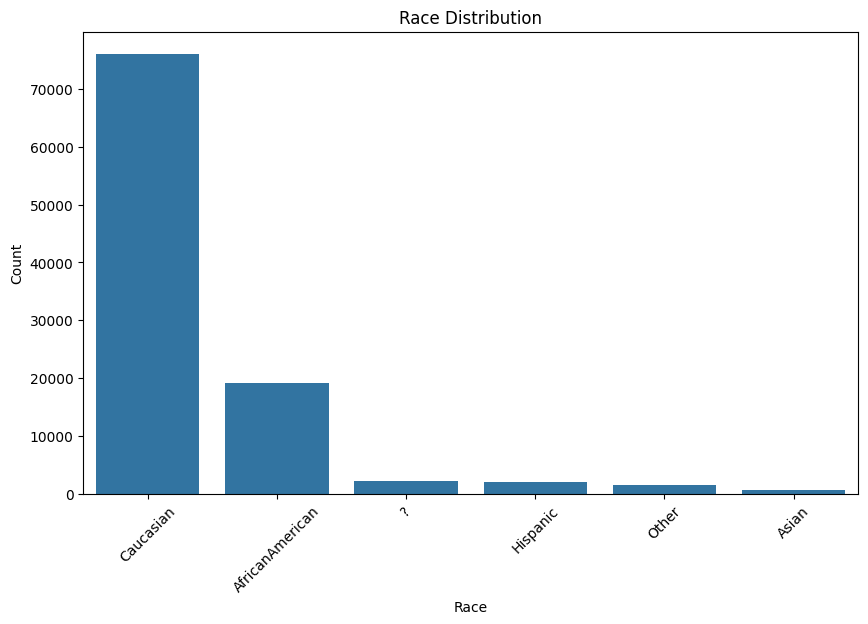

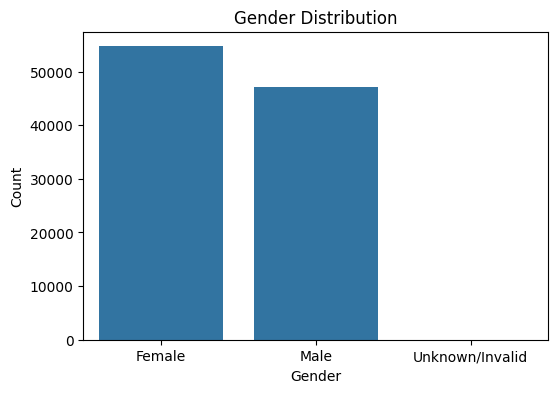

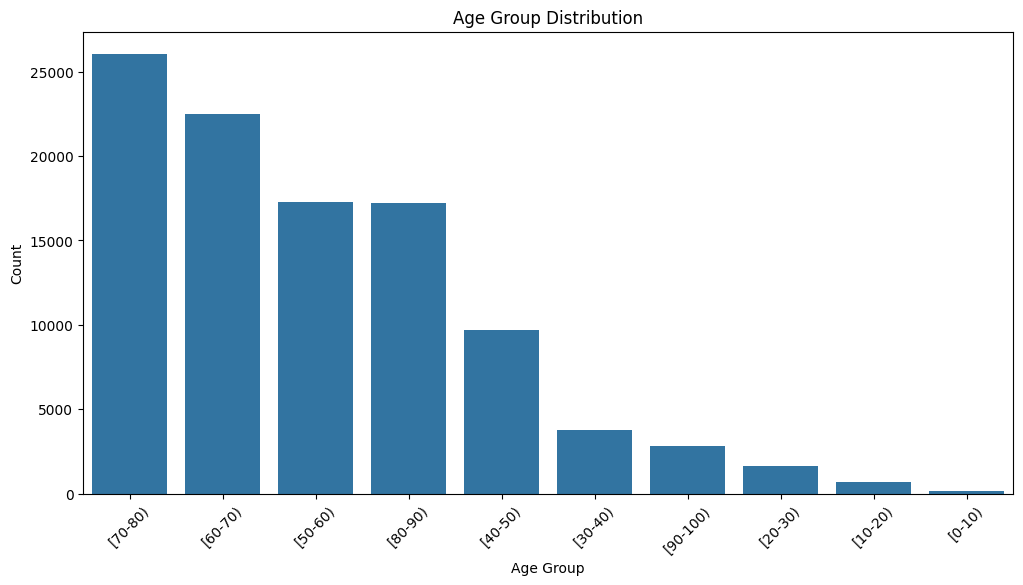

In [ ]:
# Patient Demographics (Race, Gender, Age) / 患者人口统计信息（种族、性别、年龄）
print("\nPatient Demographics Summary:")
print("Race Counts:")
print(df['race'].value_counts())
print("\nGender Counts:")
print(df['gender'].value_counts())
print("\nAge Group Counts:")
print(df['age'].value_counts())

# Count plot for Race / 种族统计图
plt.figure(figsize=(10, 6))
sns.countplot(x='race', data=df, order=df['race'].value_counts().index)
plt.title('Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count plot for Gender / 性别统计图
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, order=df['gender'].value_counts().index)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Count plot for Age / 年龄统计图
plt.figure(figsize=(12, 6))
sns.countplot(x='age', data=df, order=df['age'].value_counts().index)
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Race: Most patients are Caucasian, accounting for 76,099 people. The second is African American, accounting for 19,210 people. Some data records are missing and marked as (?), accounting for 2,273 people.

Gender: There are 54,708 female patients, slightly more than male patients (47,055 people). There are 3 records marked as Unknown/Invalid.

Age distribution: Patients are mainly concentrated in the age group of 50-90 years old. Among them, the largest number of patients are 70-80 years old, with 26,068 people. It shows that diabetes has a greater impact on the elderly group.

This information shows that the diabetic patients in this dataset are mainly middle-aged and elderly Caucasians, with slightly more females than males.

种族：大部分患者为Caucasian（高加索人），占76,099人。其次为AfricanAmerican（非裔美国人），占19,210人。有部分数据记录缺失，被标记为（?），占2,273人。

性别：女性患者为54,708人，略多于男性（47,055人）。有3条记录被标记为Unknown/Invalid。

年龄分布：患者主要集中在50-90岁年龄段。其中70-80岁的患者最多，有26,068人。表明糖尿病对老年群体影响较大。

这些信息表明该数据集中的糖尿病患者主要为中老年Caucasian，女性略多于男性。

2.Patient Admission Information / 患者病历信息


Patient Admission Information Summary:
Admission Type ID Counts:
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

Discharge Disposition ID Counts:
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

Admission Source ID Counts:
admission_source_id
7     57494
1     29565
17     6781
4      3187
6      2264
2      1104
5       855
3       187
20      161
9       125
8        16
22       12
10        8
14        2
11        2
25        2
13        1
Name: count, dtype: int64

Time in Hospital Summary:
count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%    

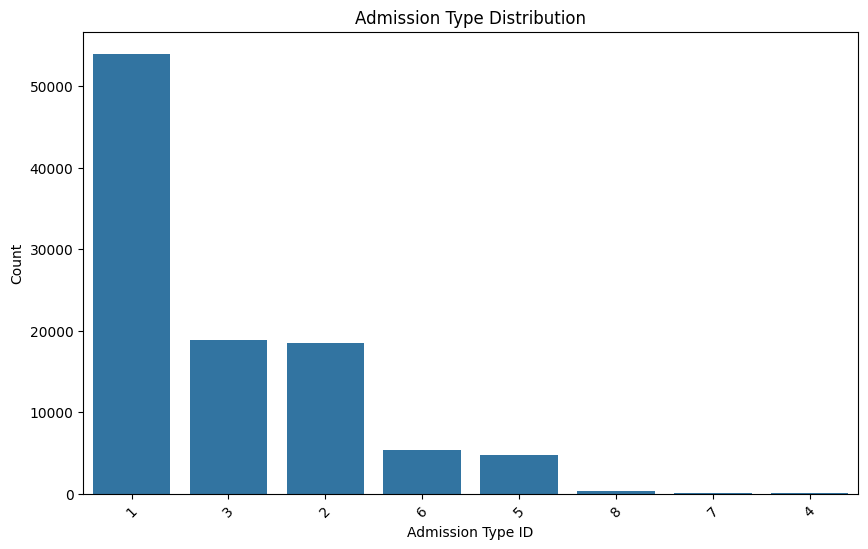

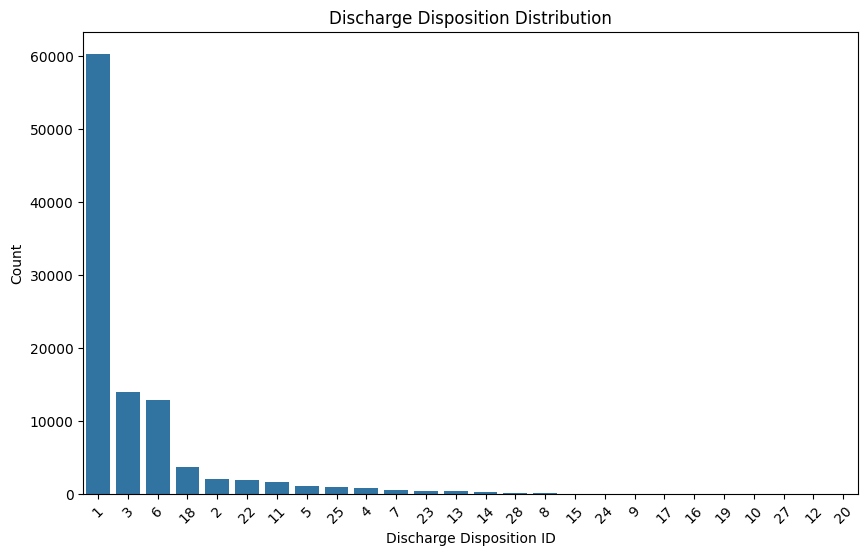

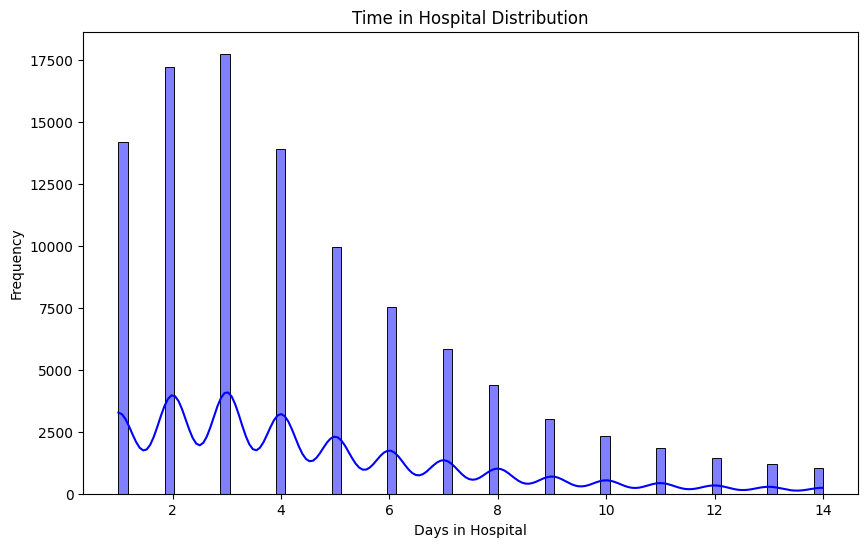

In [ ]:
# Patient Admission Information / 患者病历信息
print("\nPatient Admission Information Summary:")
print("Admission Type ID Counts:")
print(df['admission_type_id'].value_counts())
print("\nDischarge Disposition ID Counts:")
print(df['discharge_disposition_id'].value_counts())
print("\nAdmission Source ID Counts:")
print(df['admission_source_id'].value_counts())
print("\nTime in Hospital Summary:")
print(df['time_in_hospital'].describe())

# Count plot for Admission Type ID / 入院类型统计
plt.figure(figsize=(10, 6))
sns.countplot(x='admission_type_id', data=df, order=df['admission_type_id'].value_counts().index)
plt.title('Admission Type Distribution')
plt.xlabel('Admission Type ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count plot for Discharge Disposition ID / 出院状态统计
plt.figure(figsize=(10, 6))
sns.countplot(x='discharge_disposition_id', data=df, order=df['discharge_disposition_id'].value_counts().index)
plt.title('Discharge Disposition Distribution')
plt.xlabel('Discharge Disposition ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Distribution of Time in Hospital / 住院时间分布
plt.figure(figsize=(10, 6))
sns.histplot(df['time_in_hospital'], kde=True, color='blue')
plt.title('Time in Hospital Distribution')
plt.xlabel('Days in Hospital')
plt.ylabel('Frequency')
plt.show()

Admission type (admission_type_id)

Patients were admitted to the hospital most frequently in an emergency, with type 1 (Emergency) accounting for the majority (53,990 times).

Discharge status (discharge_disposition_id)

Discharged to home (ID1 Discharged to home) was the most common discharge status, accounting for 60,234 times.

Admission source (admission_source_id)

Admission source 7 (Emergency Room) accounted for the majority, with a total of 57,494 times.

Length of stay (time_in_hospital)

Most patients were admitted to the hospital for no more than 6 days, indicating that most patients had a short hospital stay.

Overall, most patients were admitted to the hospital through the emergency department, and most returned home after discharge, with the length of stay mainly concentrated within a few days.

入院类型 (admission_type_id)

患者紧急入院最多，入院类型1(Emergency)占大部分（53,990次）。

出院状态 (discharge_disposition_id)

出院回家(ID1 Discharged to home)是最常见的出院状态，占60,234次。

入院来源 (admission_source_id)

入院来源7（ Emergency Room）占大多数，共 57,494 次。

住院时间 (time_in_hospital)

大部分患者住院时间不超过 6 天，表明大多数患者的住院时间较短。

总体来看，大部分患者是通过急诊入院，出院后大多数回家，住院时间主要集中在几天内。

**3.Analysis of Diagnoses / 诊断详细分析**


Diagnosis Information Summary:
Primary Diagnosis (diag_1) Counts:
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

Secondary Diagnosis (diag_2) Counts:
diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
496    3305
599    3288
403    2823
414    2650
411    2566
Name: count, dtype: int64

Tertiary Diagnosis (diag_3) Counts:
diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
414     3664
496     2605
403     2357
585     1992
272     1969
Name: count, dtype: int64

Max Glucose Serum Counts:
max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64

A1C Result Counts:
A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64


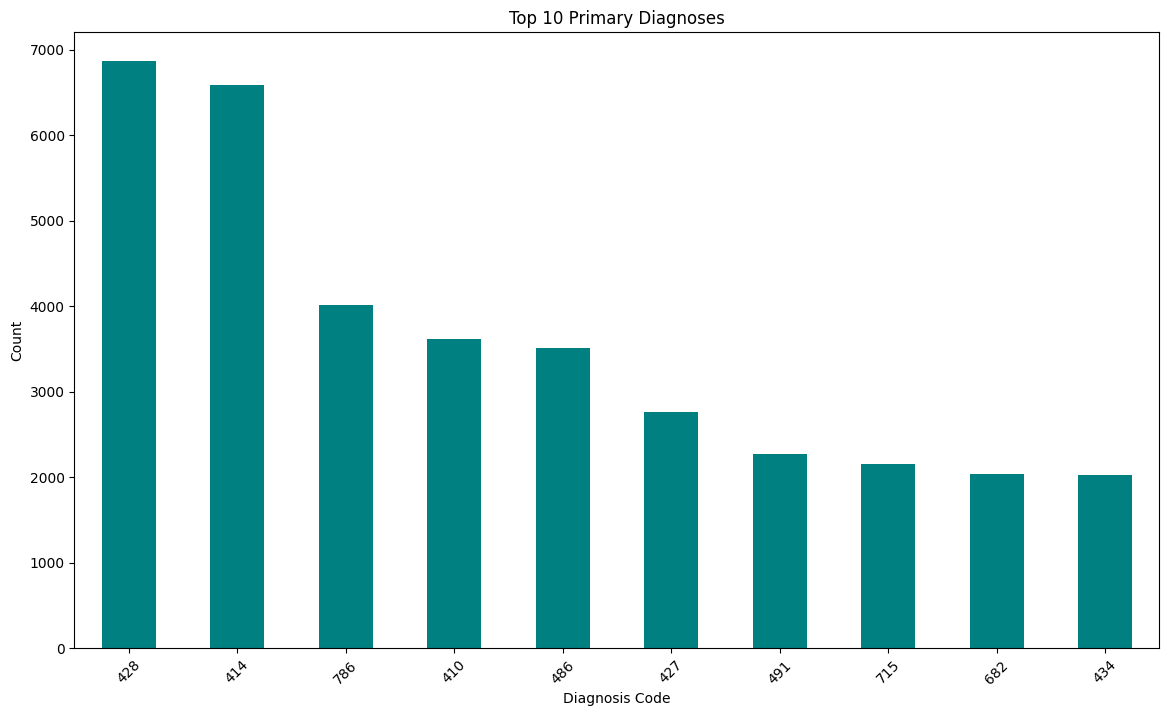

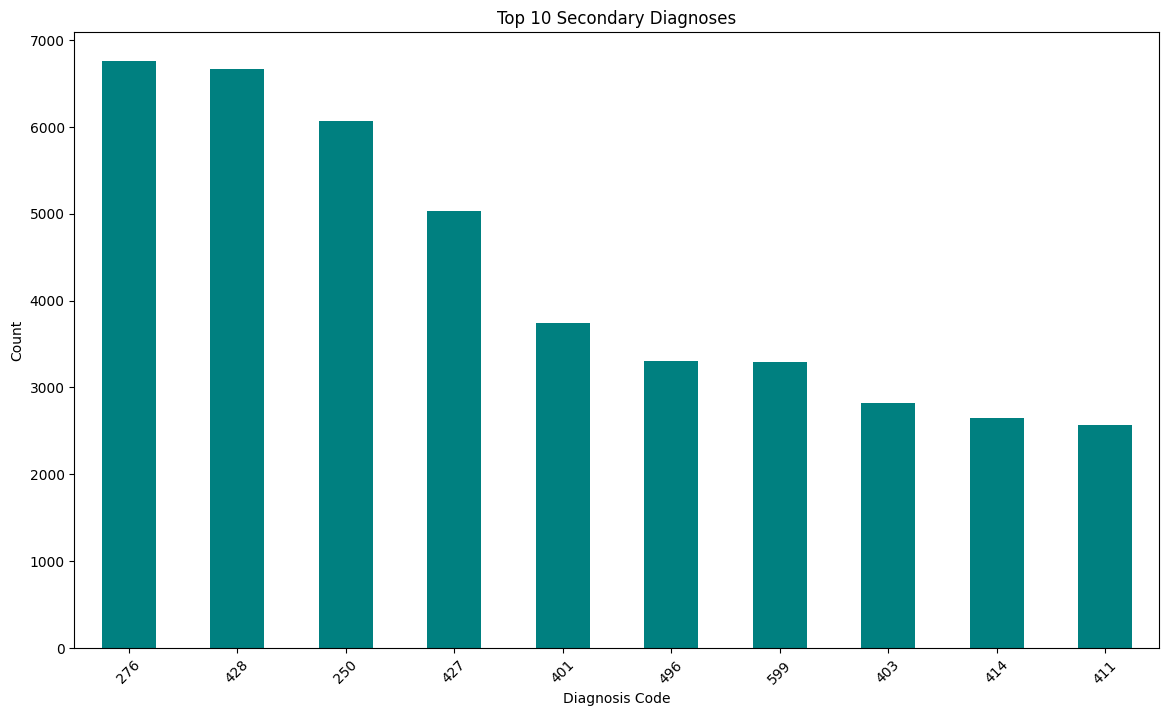

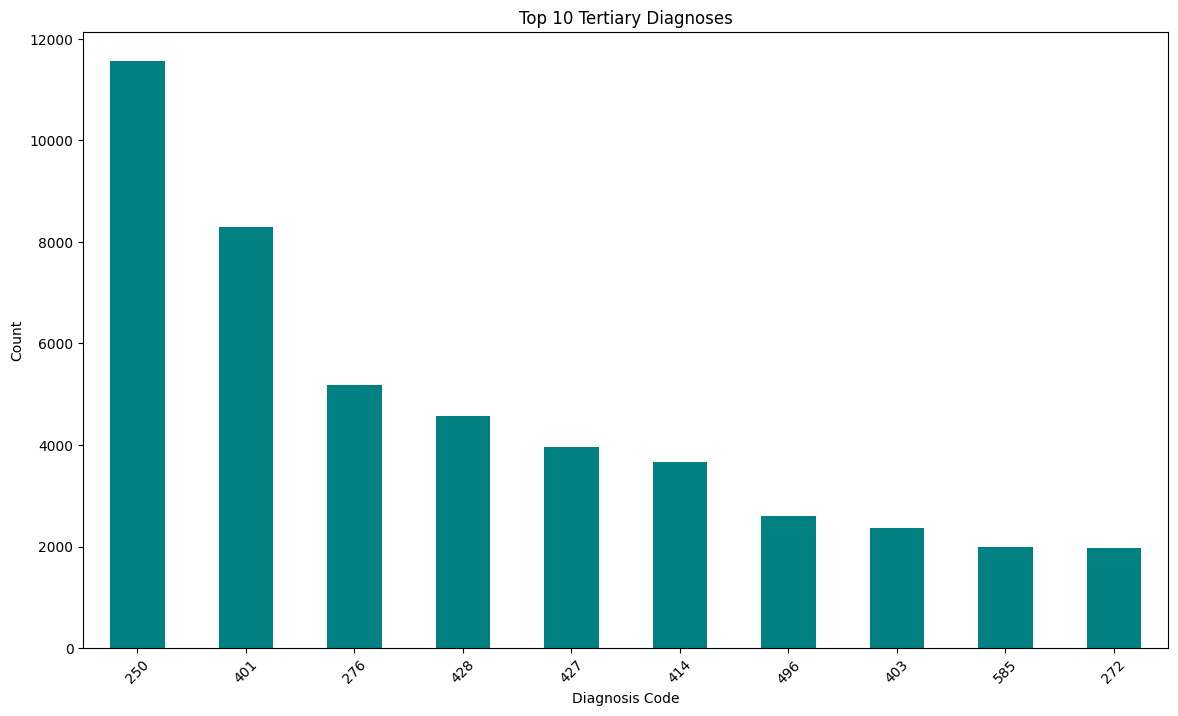

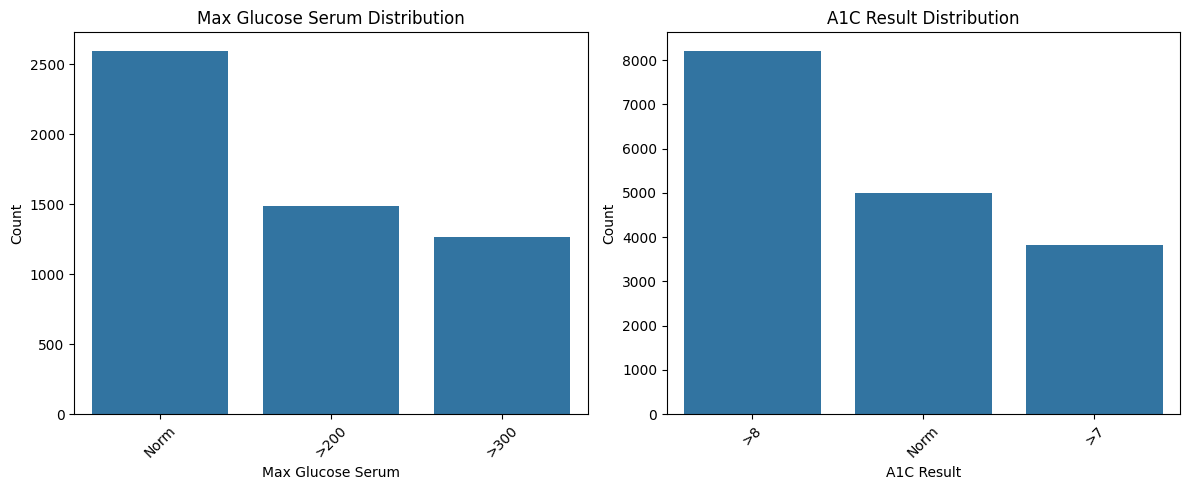

In [ ]:
# 3. Analysis of Diagnoses / 诊断详细分析
print("\nDiagnosis Information Summary:")
print("Primary Diagnosis (diag_1) Counts:")
print(df['diag_1'].value_counts().head(10))
print("\nSecondary Diagnosis (diag_2) Counts:")
print(df['diag_2'].value_counts().head(10))
print("\nTertiary Diagnosis (diag_3) Counts:")
print(df['diag_3'].value_counts().head(10))
print("\nMax Glucose Serum Counts:")
print(df['max_glu_serum'].value_counts())
print("\nA1C Result Counts:")
print(df['A1Cresult'].value_counts())

# Count of Primary Diagnosis (diag_1) / 主诊断统计
plt.figure(figsize=(14, 8))
df['diag_1'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Primary Diagnoses')
plt.xlabel('Diagnosis Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count of Secondary Diagnosis (diag_2) / 第二诊断统计
plt.figure(figsize=(14, 8))
df['diag_2'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Secondary Diagnoses')
plt.xlabel('Diagnosis Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count of Tertiary Diagnosis (diag_3) / 第三诊断统计
plt.figure(figsize=(14, 8))
df['diag_3'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Tertiary Diagnoses')
plt.xlabel('Diagnosis Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Max Glucose Serum and A1C Result Distribution / 最大葡萄糖血清和A1C结果分布
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='max_glu_serum', data=df, order=df['max_glu_serum'].value_counts().index)
plt.title('Max Glucose Serum Distribution')
plt.xlabel('Max Glucose Serum')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(x='A1Cresult', data=df, order=df['A1Cresult'].value_counts().index)
plt.title('A1C Result Distribution')
plt.xlabel('A1C Result')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The 3 diagnostic results show that many patients have diabetes and its complications. Patients with diabetes (code 250) are usually accompanied by complications such as congestive heart failure (code 428) and coronary artery disease (code 414), respiratory symptoms (code 786) and acute myocardial infarction (code 410), fluid and electrolyte disorders (code 276) and hypertension (code 401).

The maximum blood sugar serum result was normal only in 2597 times, indicating that fewer patients had blood sugar control. Only 4990 HbA1C tests were recorded as normal, which means that most patients had unsatisfactory results in the glycated hemoglobin test. Patients generally had poor blood sugar control.

从3次诊断结果表明许多患者存在糖尿病及其并发症。患者患有糖尿病(代码 250)的同时，通常也伴随着充血性心力衰竭(代码 428)和冠状动脉疾病(代码 414)、呼吸系统症状(代码 786)和急性心肌梗死(代码 410)、体液和电解质紊乱(代码 276)以及高血压(代码 401)等并发症。

最大血糖血清结果正常仅占2597次，表示有血糖控制的患者较少。HbA1C测试只有4990次记录为正常，意味着大部分患者在糖化血红蛋白测试中结果不理想。患者血糖控制普遍较差。


**4.Patient Medication / 患者用药情况**


Medication Usage Summary (Sorted by Usage):
insulin: Not Used = 47383, Used = 54383
metformin: Not Used = 81778, Used = 19988
glipizide: Not Used = 89080, Used = 12686
glyburide: Not Used = 91116, Used = 10650
pioglitazone: Not Used = 94438, Used = 7328
rosiglitazone: Not Used = 95401, Used = 6365
glimepiride: Not Used = 96575, Used = 5191
repaglinide: Not Used = 100227, Used = 1539
glyburide-metformin: Not Used = 101060, Used = 706
nateglinide: Not Used = 101063, Used = 703
acarbose: Not Used = 101458, Used = 308
chlorpropamide: Not Used = 101680, Used = 86
tolazamide: Not Used = 101727, Used = 39
miglitol: Not Used = 101728, Used = 38
tolbutamide: Not Used = 101743, Used = 23
glipizide-metformin: Not Used = 101753, Used = 13
troglitazone: Not Used = 101763, Used = 3
metformin-rosiglitazone: Not Used = 101764, Used = 2
acetohexamide: Not Used = 101765, Used = 1
glimepiride-pioglitazone: Not Used = 101765, Used = 1
metformin-pioglitazone: Not Used = 101765, Used = 1
citoglipton: Not U

<ipython-input-32-848a361c55e1>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=used_counts, y=med_names, palette='viridis')


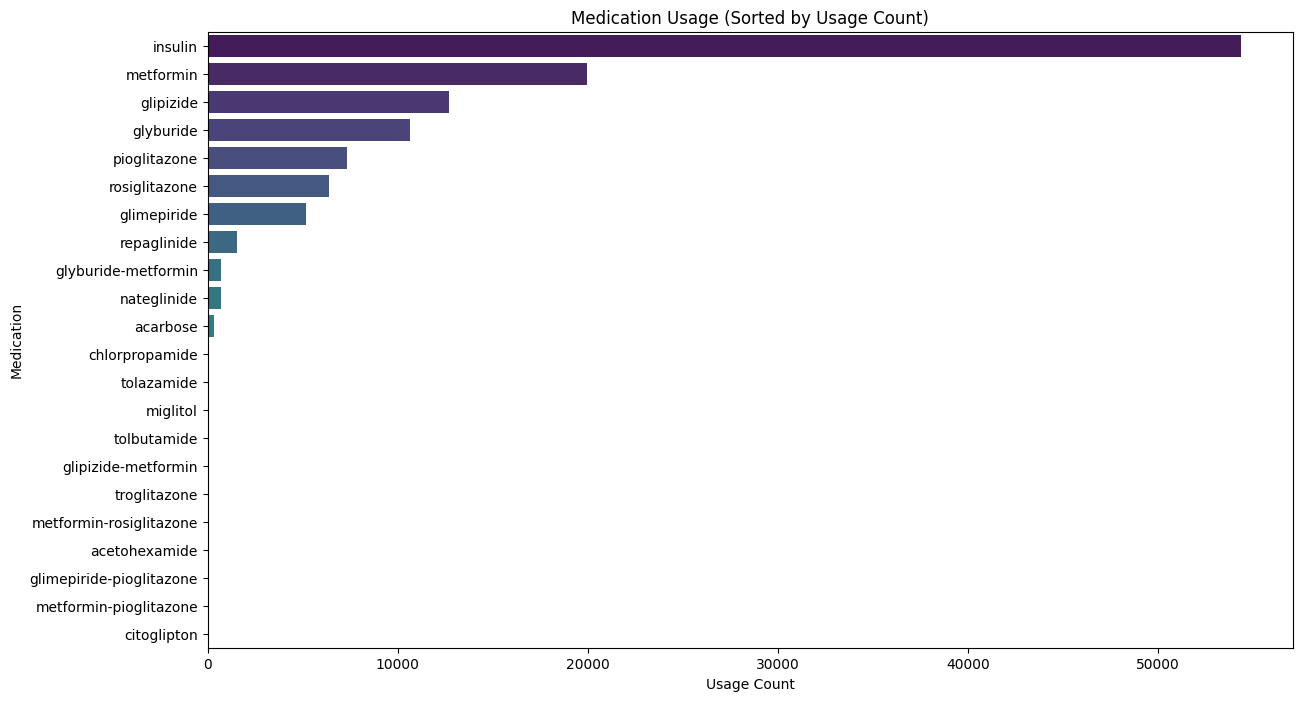

In [ ]:
# Count of Medication Usage / 药物使用统计
medications = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
    'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'citoglipton', 'insulin',
    'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

medication_usage = {}
for med in medications:
    used_count = df[med].value_counts().get('Steady', 0) + df[med].value_counts().get('Up', 0) + df[med].value_counts().get('Down', 0)
    not_used_count = df[med].value_counts().get('No', 0)
    medication_usage[med] = (not_used_count, used_count)

# Sort medications by usage count in descending order / 按照药物被使用数量降序排序
sorted_medication_usage = dict(sorted(medication_usage.items(), key=lambda item: item[1][1], reverse=True))

# Print medication usage summary / 打印药物使用情况摘要
print("\nMedication Usage Summary (Sorted by Usage):")
for med, usage in sorted_medication_usage.items():
    print(f"{med}: Not Used = {usage[0]}, Used = {usage[1]}")

# Visualize sorted medication usage / 可视化药物使用情况
med_names = list(sorted_medication_usage.keys())
used_counts = [usage[1] for usage in sorted_medication_usage.values()]

plt.figure(figsize=(14, 8))
sns.barplot(x=used_counts, y=med_names, palette='viridis')
plt.title('Medication Usage (Sorted by Usage Count)')
plt.xlabel('Usage Count')
plt.ylabel('Medication')
plt.show()


In terms of drug use, the most commonly used drug is insulin, followed by metformin. The use of these two drugs is much higher than other drugs, indicating that they are the main drugs in diabetes management.

In addition, glipizide, glyburide, pioglitazone, rosiglitazone and glimepiride are also widely used. These drugs are mainly used to control blood sugar levels and manage diabetes symptoms.

The use rate of other drugs is low or not used.

在药物使用方面，最常用的药物是胰岛素（insulin），其次是二甲双胍（metformin）。这两种药物的使用量远高于其他药物，表明它们是糖尿病管理中的主要药物。

此外，glipizide、glyburide、pioglitazone、rosiglitazone和glimepiride也被广泛使用。这些药物主要用于控制血糖水平和管理糖尿病症状。

其他药物的使用率较低或没有被使用。


**5.Readmission Analysis / 再入院情况分析**


Readmission Information Summary:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


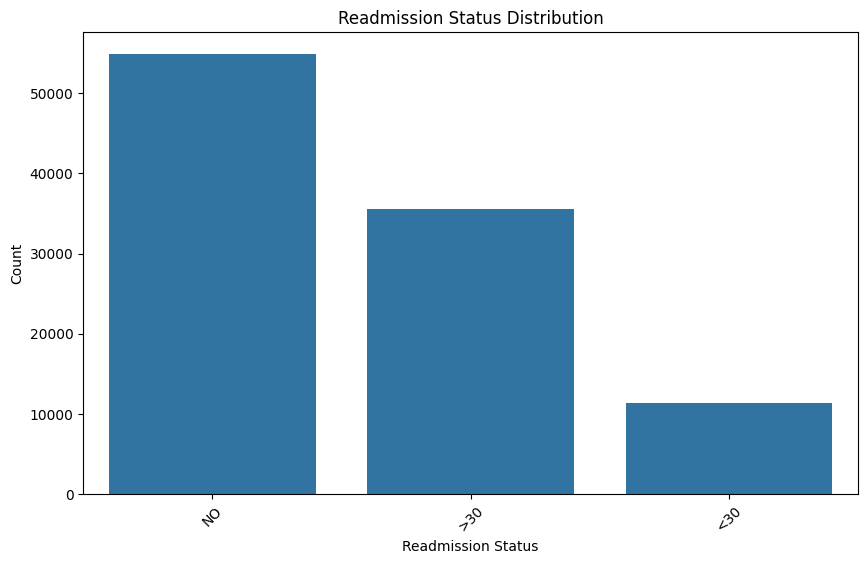

In [ ]:
# Readmission Analysis / 再入院情况分析
print("\nReadmission Information Summary:")
print(df['readmitted'].value_counts())

#Readmission Analysis / 再入院情况分析
plt.figure(figsize=(10, 6))
sns.countplot(x='readmitted', data=df, order=df['readmitted'].value_counts().index)
plt.title('Readmission Status Distribution')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

There were 54,864 patients who were not readmitted (NO), accounting for more than half of the total. This indicates that most patients were not readmitted within a short period of time after their first discharge.

There were 35,545 patients who were readmitted more than 30 days later (">30"). There were 11,357 patients who were readmitted within 30 days ("<30"). Overall, the higher proportion of patients who were readmitted indicates that the risk of recurrence is higher.

没有再入院(NO)的患者共有54,864人，约占总数的一半以上。这表明大部分患者在首次出院后并未在较短时间内再次入院。

超过30天后再入院(">30")的患者有35,545人。在30天内再入院("<30")的患者有11,357 人。总体来看，再入院的患者比例较高，表明患者复发风险较高。

# **Data Preprocessing**

**Data Preprocessing Steps:**

**Load Data**: Load the dataset and read the CSV file into a DataFrame.

**Handle Missing Values**:

Replace missing indicators (e.g., '?', 'Unknown/Invalid') with NaN.

Drop high-missing-value columns: 'weight', 'payer_code', 'medical_specialty'.

Fill categorical columns with the mode and numerical columns with the mean.

**Remove Duplicates**:

Remove duplicate records based on 'patient_nbr'.

**Filter Records**:

Retain patients who used at least two medications and remove records that don't meet this criterion.

**Feature Cleanup:**

Remove irrelevant columns like 'encounter_id' and 'patient_nbr'.
Drop low-frequency medication-related columns.

**Feature Transformation**:

Convert age ranges to midpoints (e.g., '[0-10)' → 5).

Label encode categorical variables (e.g., 'race', 'gender', 'readmitted').

Classify ICD-9 codes (e.g., 'diag_1', 'diag_2', 'diag_3') into predefined categories and label encode them.

**Standardization**:

Exclude medication-related columns.
Standardize all other numerical features to have a mean of 0 and a standard deviation of 1.

Save Processed Data: Export the preprocessed dataset to a CSV file.


数据预处理总结

加载数据： 加载数据集，将 CSV 文件读取为 DataFrame。

处理缺失值：

将缺失值标识（如 '?'、'Unknown/Invalid'）替换为 NaN。

删除高缺失率的列：'weight'、'payer_code'、'medical_specialty'。

分类变量使用众数填充，数值型变量使用均值填充。

删除重复值：
根据 'patient_nbr' 删除重复记录。

筛选记录： 保留使用至少两种药物的患者，删除不满足条件的记录。

特征清理：

删除无关列，如 'encounter_id' 和 'patient_nbr'。
删除低频药物相关列。

特征转换：

将年龄区间转换为中位值（如 '[0-10)' → 5）。

对分类变量（如 'race'、'gender'、'readmitted'）进行标签编码。

将 ICD-9 诊断列（如 'diag_1'、'diag_2'、'diag_3'）分类到预定义类别，并进行标签编码。

标准化：

排除药物相关列。
对其余数值型特征进行标准化，使均值为 0，标准差为 1。

保存处理后的数据： 将预处理后的数据集导出为 CSV 文件

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset / 加载数据集
file_path = '/content/drive/MyDrive/diabetic_dataset.csv'
data = pd.read_csv(file_path)

# Step 1: Handle missing values / 第一步：处理缺失值
data.replace(['?', 'Unknown/Invalid'], np.nan, inplace=True)
columns_to_drop = ['weight', 'payer_code', 'medical_specialty']
data = data.drop(columns=columns_to_drop, errors='ignore')

categorical_cols = ['race', 'gender']
for col in categorical_cols:
    data.loc[:, col] = data[col].fillna(data[col].mode()[0])

numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data.loc[:, col] = data[col].fillna(data[col].mean())

# Step 2: Remove duplicate records / 删除重复记录
data = data.drop_duplicates(subset='patient_nbr', keep='first')

# Step 3: Filter specific records / 筛选特定记录
medication_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
data['medication_count'] = data[medication_columns].apply(lambda x: sum(x != 'No'), axis=1)
data = data[data['medication_count'] >= 2]

# Remove irrelevant columns / 删除无关列
columns_to_remove = [
    'encounter_id', 'patient_nbr', 'change', 'diabetesMed',
    'chlorpropamide', 'acarbose', 'miglitol', 'troglitazone',
    'examide', 'citoglipton', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'acetohexamide', 'tolbutamide',
    'tolazamide', 'medication_count'
]
data = data.drop(columns=columns_to_remove, errors='ignore')

# Step 4: Feature Transformation / 特征转换
age_mapping = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
data.loc[:, 'age'] = data['age'].map(age_mapping)

# Label Encoding for categorical variables / 分类变量的标签编码
categorical_cols_label = ['race', 'gender', 'readmitted', 'max_glu_serum', 'A1Cresult']
label_mappings = {}
for col in categorical_cols_label:
    le = LabelEncoder()
    data.loc[:, col] = le.fit_transform(data[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Print label encoding mappings / 打印分类变量编码映射
print("Label Encoding Mappings:")
for col, mapping in label_mappings.items():
    print(f"{col}: {mapping}")

# Classify ICD-9 codes / 分类ICD-9代码
diagnosis_columns = ['diag_1', 'diag_2', 'diag_3']
def classify_icd9_code(icd_code):
    try:
        code = float(icd_code)
        if 390 <= code <= 459:
            return 'circulatory'
        elif code == 250:
            return 'diabetes'
        elif 520 <= code <= 579:
            return 'digestive'
        elif 580 <= code <= 629:
            return 'genitourinary'
        elif 800 <= code <= 999:
            return 'injuries'
        elif 710 <= code <= 739:
            return 'musculoskeletal'
        elif 140 <= code <= 239:
            return 'neoplasms'
        elif 460 <= code <= 519:
            return 'respiratory'
        else:
            return 'other'
    except:
        return 'other'

label_mappings_diag = {}
for col in diagnosis_columns:
    data.loc[:, col] = data[col].apply(classify_icd9_code)
    encoder = LabelEncoder()
    data.loc[:, col] = encoder.fit_transform(data[col])
    label_mappings_diag[col] = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

# Print diagnosis column mappings / 打印诊断列编码映射
print("\nDiagnosis Columns Label Encoding Mappings:")
for col, mapping in label_mappings_diag.items():
    print(f"{col}: {mapping}")

# Step 5: Standardize all numerical features except medication columns / 标准化所有数值特征（排除药物列）
# Select all columns except medication columns / 排除不需要标准化的列
columns_to_exclude = medication_columns
columns_to_standardize = [col for col in data.columns if col not in columns_to_exclude]

# Standardize selected columns / 标准化选定列
scaler = StandardScaler()
data[columns_to_standardize] = scaler.fit_transform(data[columns_to_standardize])

# Print standardized numerical columns / 打印标准化后的数值型列
print("\nStandardized Numerical Columns (First Few Rows):")
print(data[columns_to_standardize].head())

# Save processed dataset / 保存处理后的数据集
output_path = '/content/drive/MyDrive/processed_diabetic_dataset.csv'
data.to_csv(output_path, index=False)
print(f"Processed data saved to {output_path}")

Label Encoding Mappings:
race: {'AfricanAmerican': 0, 'Asian': 1, 'Caucasian': 2, 'Hispanic': 3, 'Other': 4}
gender: {'Female': 0, 'Male': 1}
readmitted: {'<30': 0, '>30': 1, 'NO': 2}
max_glu_serum: {'>200': 0, '>300': 1, 'Norm': 2, nan: 3}
A1Cresult: {'>7': 0, '>8': 1, 'Norm': 2, nan: 3}

Diagnosis Columns Label Encoding Mappings:
diag_1: {'circulatory': 0, 'diabetes': 1, 'digestive': 2, 'genitourinary': 3, 'injuries': 4, 'musculoskeletal': 5, 'neoplasms': 6, 'other': 7, 'respiratory': 8}
diag_2: {'circulatory': 0, 'diabetes': 1, 'digestive': 2, 'genitourinary': 3, 'injuries': 4, 'musculoskeletal': 5, 'neoplasms': 6, 'other': 7, 'respiratory': 8}
diag_3: {'circulatory': 0, 'diabetes': 1, 'digestive': 2, 'genitourinary': 3, 'injuries': 4, 'musculoskeletal': 5, 'neoplasms': 6, 'other': 7, 'respiratory': 8}

Standardized Numerical Columns (First Few Rows):
        race    gender       age  admission_type_id  discharge_disposition_id  \
4   0.347321  1.034517 -1.496439          -0.749631 